# 🛍️ Customer Segmentation Using Unsupervised Learning
## Data Science Internship Project

---

## 📌 Project Overview

In today's highly competitive retail landscape, understanding **who your customers are** and **how they behave** is no longer optional — it is a business necessity. This project applies **unsupervised machine learning techniques** to segment mall customers based on their demographic and spending characteristics.

By identifying distinct customer groups, businesses can:
- Design **personalized marketing campaigns** for each group
- **Retain high-value customers** through loyalty programs
- **Re-engage dormant customers** with targeted offers
- **Optimize product placement** and promotions

---

## 🎯 Objective

The primary objective of this project is to:

1. Perform thorough **Exploratory Data Analysis (EDA)** on the Mall Customers dataset
2. Apply **K-Means Clustering** to discover natural customer segments
3. Use **PCA** and **t-SNE** for dimensionality reduction and cluster visualization
4. Derive **actionable marketing strategies** tailored to each customer segment

---

## 💼 Business Significance

Customer segmentation is one of the most widely used techniques in:
- **Retail & E-Commerce** (Amazon, Walmart)
- **Banking & Finance** (customer credit profiling)
- **Telecom** (churn prediction per segment)
- **Healthcare** (patient grouping)

Instead of treating every customer the same, segmentation allows businesses to allocate marketing budgets more wisely and maximize ROI.

---

## 🔍 Why K-Means Clustering?

K-Means is ideal here because:
- The dataset has **no target labels** (unsupervised setting)
- We want to group customers into **compact, well-separated clusters**
- K-Means is **fast, scalable, and interpretable** for business stakeholders

---


## 📦 Section 2: Importing Required Libraries

We begin by importing all the libraries needed throughout this project.


In [1]:
# Standard data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Machine learning – preprocessing & clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Make plots look nice and consistent throughout
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
sns.set_style('whitegrid')
sns.set_palette('Set2')

print("✅ All libraries imported successfully!")


✅ All libraries imported successfully!


## 📂 Section 3: Loading the Dataset

We load the Mall Customers CSV file and take an initial look at the data.


In [2]:
# Loading the dataset from the provided file path
df = pd.read_csv('Mall_Customers.csv')

# First look at the data
print("🔍 First 10 rows of the dataset:")
df.head(10)


🔍 First 10 rows of the dataset:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
# Basic shape and column information
print(f"📐 Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\n📋 Column Names: {list(df.columns)}")
print(f"\n🗂️ Data Types:\n{df.dtypes}")


📐 Dataset Shape: 200 rows × 5 columns

📋 Column Names: ['CustomerID', 'Genre', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

🗂️ Data Types:
CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object


## 🔎 Section 4: Data Understanding & Exploration

### 📖 Feature Description

| Feature | Type | Description |
|---|---|---|
| `CustomerID` | Numerical | Unique identifier for each customer — not useful for analysis |
| `Genre` | Categorical | Gender of the customer (Male / Female) |
| `Age` | Numerical | Age of the customer in years |
| `Annual Income (k$)` | Numerical | Annual income of the customer in thousands of dollars |
| `Spending Score (1-100)` | Numerical | Score assigned by the mall based on customer behavior and spending patterns |

The **Spending Score** is the most important feature — a high score means the customer spends a lot at the mall.


In [4]:
# Statistical summary of all numerical features
print("📊 Statistical Summary:")
df.describe().round(2)


📊 Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


In [5]:
# Checking for missing values — important before any analysis
print("❓ Missing Values per Column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


❓ Missing Values per Column:
CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0


In [6]:
# Checking for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"🔄 Number of duplicate rows: {duplicate_count}")

# Checking unique values in categorical columns
print(f"\n👥 Gender distribution (unique values): {df['Genre'].unique()}")
print(f"📦 Total unique customers: {df['CustomerID'].nunique()}")


🔄 Number of duplicate rows: 0

👥 Gender distribution (unique values): ['Male' 'Female']
📦 Total unique customers: 200


In [7]:
# Renaming columns for easier use throughout the notebook
df.rename(columns={
    'Genre': 'Gender',
    'Annual Income (k$)': 'Annual_Income',
    'Spending Score (1-100)': 'Spending_Score'
}, inplace=True)

print("✅ Columns renamed for easier access:")
print(df.columns.tolist())
df.head()


✅ Columns renamed for easier access:
['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score']


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


## 📊 Section 5: Exploratory Data Analysis (EDA)

EDA helps us visually understand the data before applying any machine learning. We'll explore distributions, relationships, and patterns across all key features.


### 5.1 – Gender Distribution

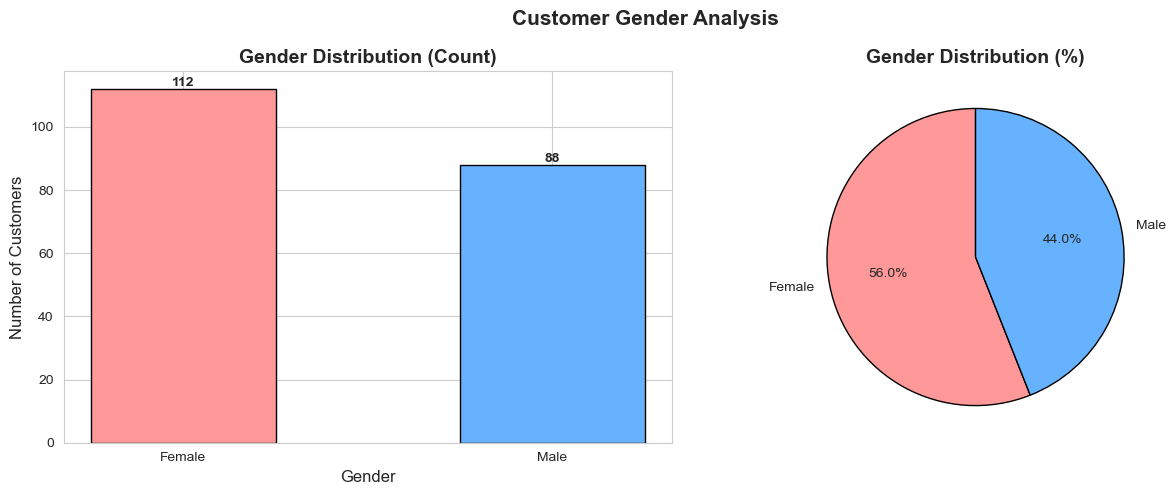

💡 Insight: The mall attracts more female customers than male customers.


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count plot for gender
gender_counts = df['Gender'].value_counts()
axes[0].bar(gender_counts.index, gender_counts.values,
            color=['#FF9999', '#66B2FF'], edgecolor='black', width=0.5)
axes[0].set_title('Gender Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index,
            autopct='%1.1f%%', colors=['#FF9999', '#66B2FF'],
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Gender Distribution (%)', fontweight='bold')

plt.suptitle('Customer Gender Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Insight: The mall attracts more female customers than male customers.")


### 5.2 – Age Distribution

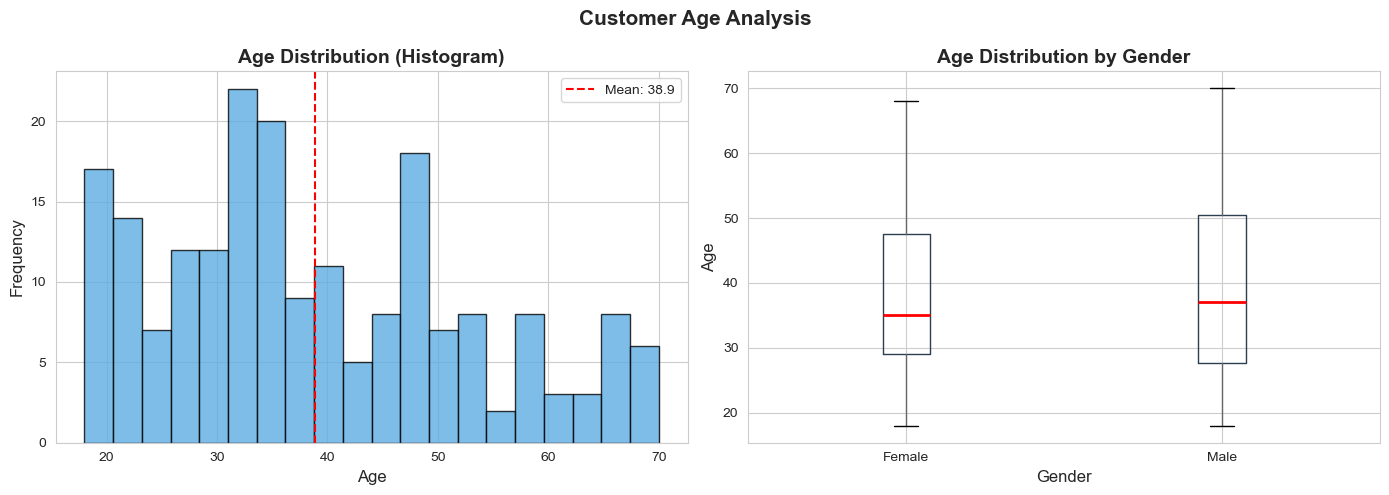

💡 Insight: Average customer age is 38.9 years.
   Youngest: 18 | Oldest: 70


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with KDE
axes[0].hist(df['Age'], bins=20, color='#5DADE2', edgecolor='black', alpha=0.8)
axes[0].set_title('Age Distribution (Histogram)', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Age'].mean(), color='red', linestyle='--', label=f"Mean: {df['Age'].mean():.1f}")
axes[0].legend()

# Box plot for age by gender
df.boxplot(column='Age', by='Gender', ax=axes[1],
           boxprops=dict(color='#2C3E50'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age Distribution by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Age')
plt.suptitle('')

plt.suptitle('Customer Age Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💡 Insight: Average customer age is {df['Age'].mean():.1f} years.")
print(f"   Youngest: {df['Age'].min()} | Oldest: {df['Age'].max()}")


### 5.3 – Annual Income Distribution

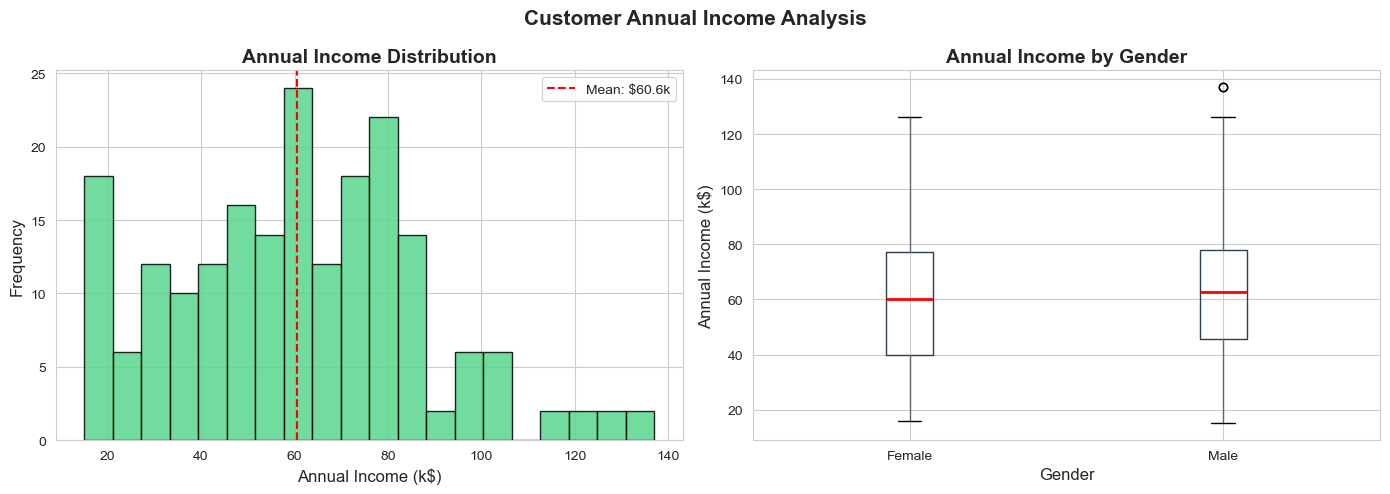

💡 Insight: Average annual income is $60.6k.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Income histogram
axes[0].hist(df['Annual_Income'], bins=20, color='#58D68D', edgecolor='black', alpha=0.85)
axes[0].set_title('Annual Income Distribution', fontweight='bold')
axes[0].set_xlabel('Annual Income (k$)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Annual_Income'].mean(), color='red', linestyle='--',
                label=f"Mean: ${df['Annual_Income'].mean():.1f}k")
axes[0].legend()

# Income by gender box plot
df.boxplot(column='Annual_Income', by='Gender', ax=axes[1],
           boxprops=dict(color='#2C3E50'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Annual Income by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Annual Income (k$)')
plt.suptitle('')

plt.suptitle('Customer Annual Income Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('income_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"💡 Insight: Average annual income is ${df['Annual_Income'].mean():.1f}k.")


### 5.4 – Spending Score Distribution

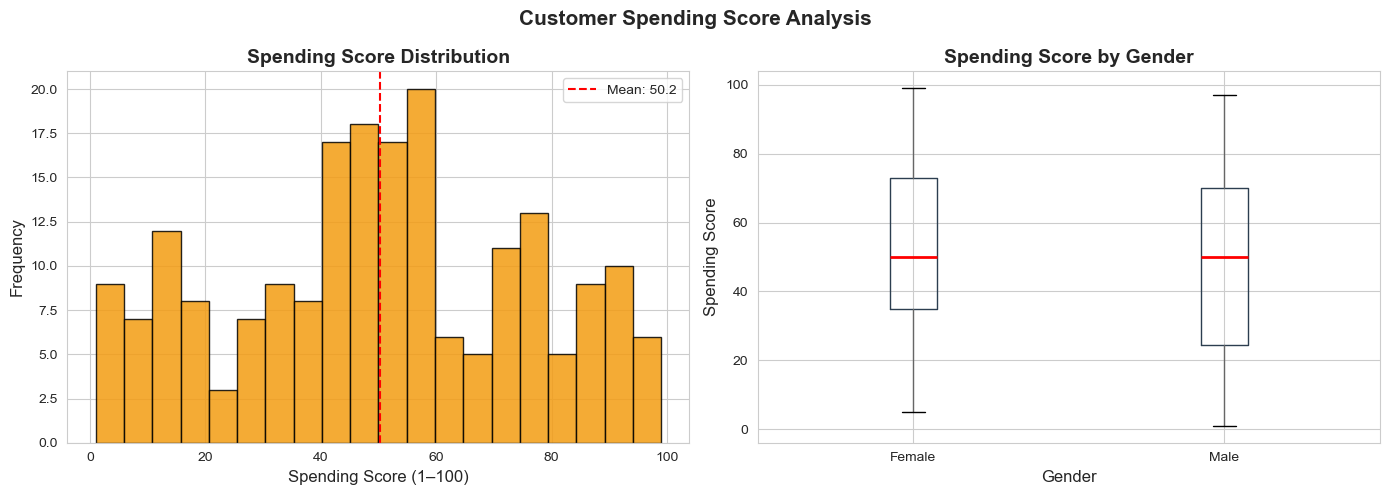

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Spending score histogram
axes[0].hist(df['Spending_Score'], bins=20, color='#F39C12', edgecolor='black', alpha=0.85)
axes[0].set_title('Spending Score Distribution', fontweight='bold')
axes[0].set_xlabel('Spending Score (1–100)')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df['Spending_Score'].mean(), color='red', linestyle='--',
                label=f"Mean: {df['Spending_Score'].mean():.1f}")
axes[0].legend()

# Spending score by gender
df.boxplot(column='Spending_Score', by='Gender', ax=axes[1],
           boxprops=dict(color='#2C3E50'),
           medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Spending Score by Gender', fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Spending Score')
plt.suptitle('')

plt.suptitle('Customer Spending Score Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('spending_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.5 – Correlation Heatmap

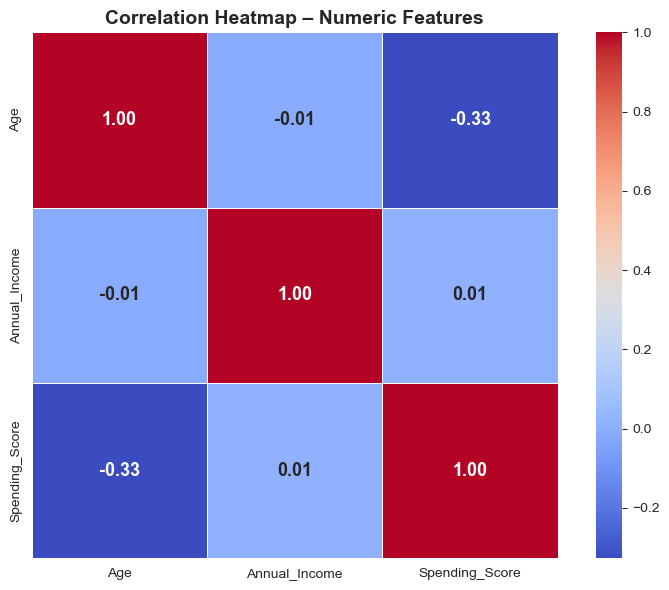

💡 Insight: There is a weak negative correlation between Age and Spending Score,
   suggesting younger customers tend to spend more at the mall.


In [12]:
# Correlation between numeric features
numeric_df = df[['Age', 'Annual_Income', 'Spending_Score']]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True,
            annot_kws={'size': 13, 'weight': 'bold'})
plt.title('Correlation Heatmap – Numeric Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Insight: There is a weak negative correlation between Age and Spending Score,")
print("   suggesting younger customers tend to spend more at the mall.")


### 5.6 – Pair Plot (Feature Relationships)

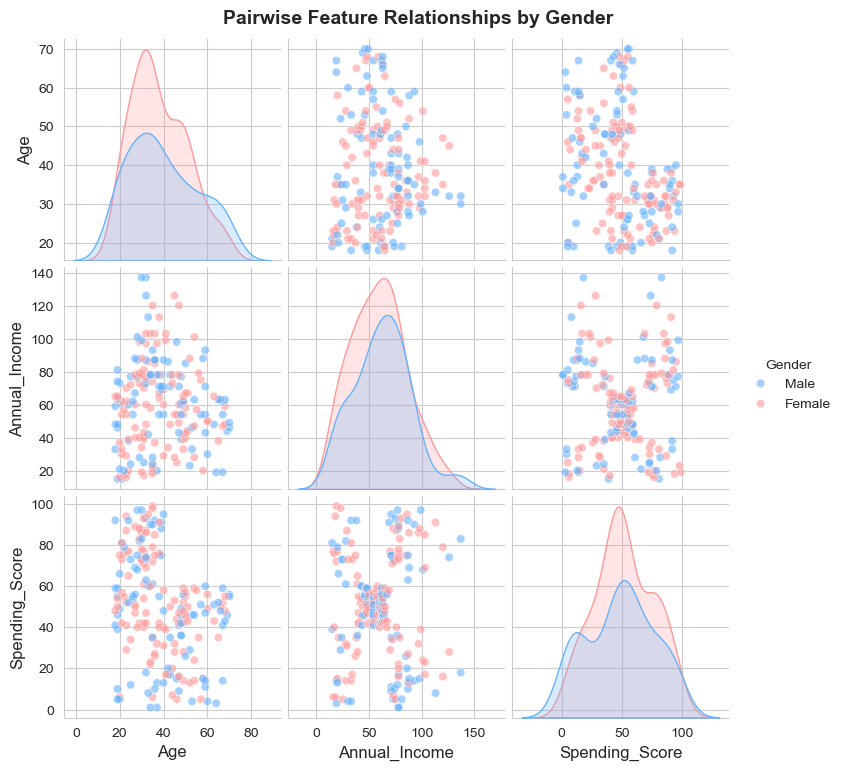

In [13]:
# Pair plot to visually explore relationships between all features
pair_df = df[['Age', 'Annual_Income', 'Spending_Score', 'Gender']].copy()
g = sns.pairplot(pair_df, hue='Gender', palette={'Male': '#66B2FF', 'Female': '#FF9999'},
                 diag_kind='kde', plot_kws={'alpha': 0.6})
g.fig.suptitle('Pairwise Feature Relationships by Gender', y=1.02, fontsize=14, fontweight='bold')
plt.savefig('pair_plot.png', dpi=120, bbox_inches='tight')
plt.show()


### 5.7 – Income vs Spending Score (Key Business View)

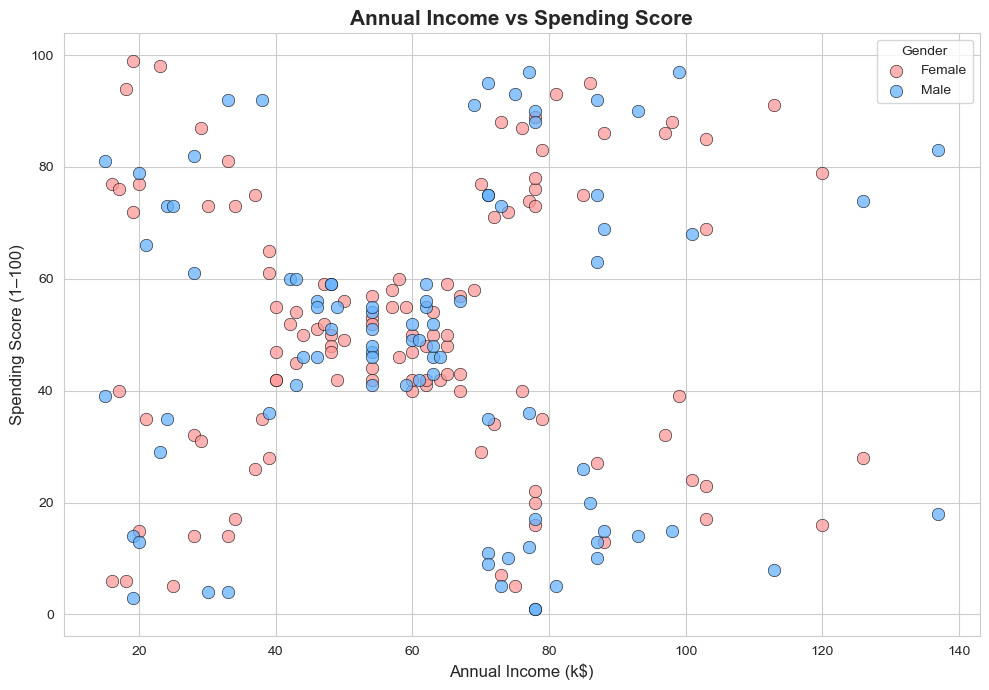

💡 Insight: We can visually spot about 5 natural customer clusters in this plot.
   This confirms K-Means will work well on Income × Spending Score features.


In [14]:
plt.figure(figsize=(10, 7))
colors = {'Male': '#66B2FF', 'Female': '#FF9999'}
for gender, group in df.groupby('Gender'):
    plt.scatter(group['Annual_Income'], group['Spending_Score'],
                label=gender, color=colors[gender], alpha=0.75, s=80, edgecolors='black', linewidth=0.5)

plt.title('Annual Income vs Spending Score', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1–100)')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('income_vs_spending.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Insight: We can visually spot about 5 natural customer clusters in this plot.")
print("   This confirms K-Means will work well on Income × Spending Score features.")


### 5.8 – Age vs Spending Score

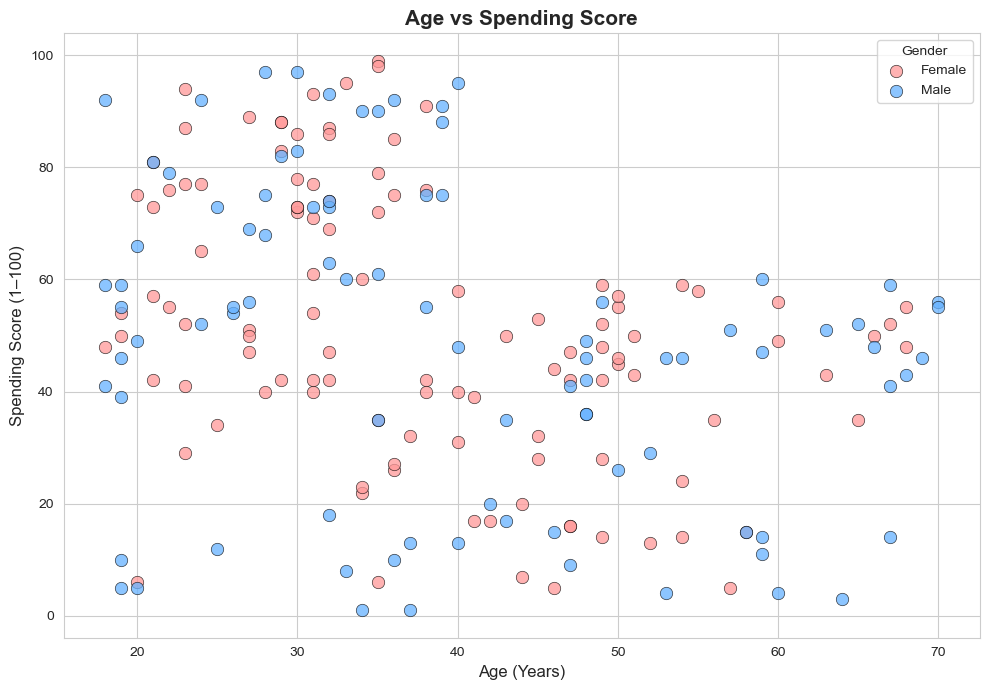

💡 Insight: Younger customers (20–35) show a wider range of spending scores,
   while older customers (50+) tend to have lower spending scores.


In [15]:
plt.figure(figsize=(10, 7))
for gender, group in df.groupby('Gender'):
    plt.scatter(group['Age'], group['Spending_Score'],
                label=gender, color=colors[gender], alpha=0.75, s=80, edgecolors='black', linewidth=0.5)

plt.title('Age vs Spending Score', fontsize=15, fontweight='bold')
plt.xlabel('Age (Years)')
plt.ylabel('Spending Score (1–100)')
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('age_vs_spending.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Insight: Younger customers (20–35) show a wider range of spending scores,")
print("   while older customers (50+) tend to have lower spending scores.")


## ⚙️ Section 6: Data Preprocessing

Before applying K-Means clustering, we need to:
1. **Select relevant features** — CustomerID is just an identifier and adds no clustering value
2. **Scale the features** — K-Means uses Euclidean distance, so features must be on the same scale

We will cluster on **Annual Income** and **Spending Score** first (classic 2D view), then on all three numeric features.


In [16]:
# Dropping CustomerID since it is just an identifier
# We also encode Gender for later use but won't include it in clustering directly
df_cluster = df[['Age', 'Annual_Income', 'Spending_Score']].copy()

# Scaling features so that no single feature dominates the distance calculations
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print("✅ Features selected and scaled.")
print(f"Shape of scaled data: {X_scaled.shape}")
print(f"\nMean of scaled features (should be ~0): {X_scaled.mean(axis=0).round(4)}")
print(f"Std of scaled features (should be ~1):  {X_scaled.std(axis=0).round(4)}")


✅ Features selected and scaled.
Shape of scaled data: (200, 3)

Mean of scaled features (should be ~0): [-0. -0. -0.]
Std of scaled features (should be ~1):  [1. 1. 1.]


In [17]:
# Also prepare the 2D version (Income + Spending Score) for classic visualization
X_2d = df[['Annual_Income', 'Spending_Score']].values
X_2d_scaled = scaler.fit_transform(X_2d)

print("✅ 2D feature set (Income & Spending) also prepared for focused clustering.")


✅ 2D feature set (Income & Spending) also prepared for focused clustering.


## 🔍 Section 7: Finding the Optimal Number of Clusters

We use two techniques to determine the best value of K (number of clusters):

1. **Elbow Method** — plots WCSS (Within-Cluster Sum of Squares) vs K; the "elbow" point is the optimal K
2. **Silhouette Score** — measures how well each data point fits its own cluster vs others; higher is better


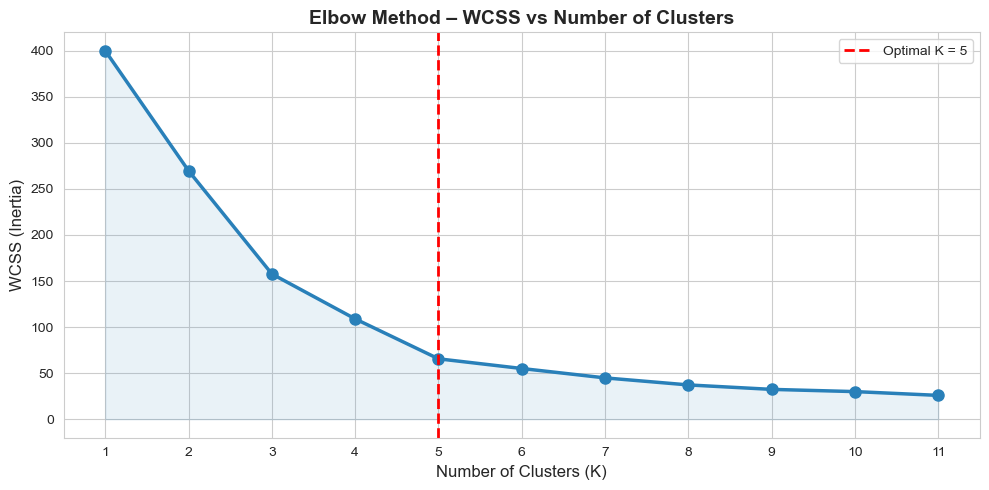

💡 The elbow clearly bends at K=5, suggesting 5 is the optimal cluster count.


In [18]:
# ── Elbow Method ──────────────────────────────────────────────────────────
wcss = []
K_range = range(1, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_2d_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, 'bo-', markersize=8, linewidth=2.5, color='#2980B9')
plt.fill_between(K_range, wcss, alpha=0.1, color='#2980B9')
plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K = 5')
plt.title('Elbow Method – WCSS vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(K_range)
plt.legend()
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 The elbow clearly bends at K=5, suggesting 5 is the optimal cluster count.")


  K= 2  →  Silhouette Score: 0.3213
  K= 3  →  Silhouette Score: 0.4666
  K= 4  →  Silhouette Score: 0.4939
  K= 5  →  Silhouette Score: 0.5547
  K= 6  →  Silhouette Score: 0.5399
  K= 7  →  Silhouette Score: 0.5281
  K= 8  →  Silhouette Score: 0.4552
  K= 9  →  Silhouette Score: 0.4571
  K=10  →  Silhouette Score: 0.4432
  K=11  →  Silhouette Score: 0.4518


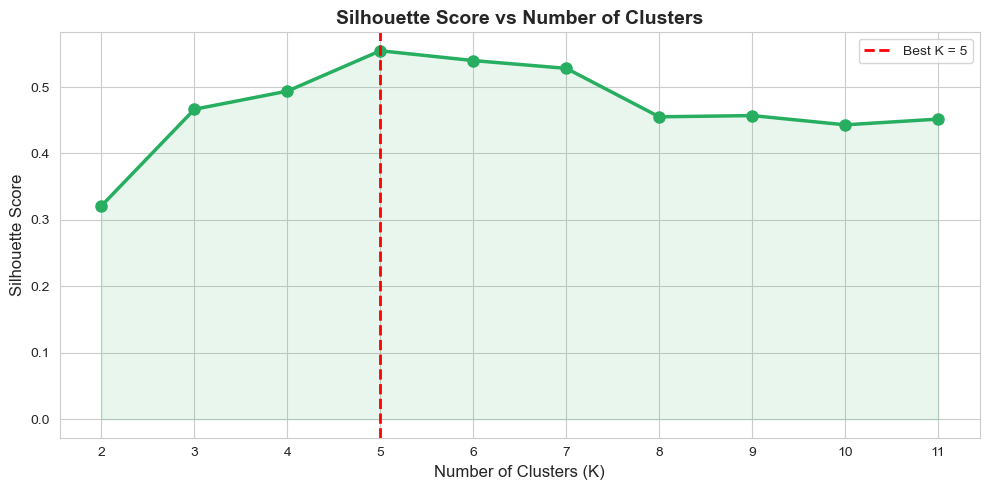


✅ Best K by Silhouette Score: 5 (Score: 0.5547)


In [19]:
# ── Silhouette Score Analysis ─────────────────────────────────────────────
silhouette_scores = []
K_range_sil = range(2, 12)  # silhouette needs at least 2 clusters

for k in K_range_sil:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_2d_scaled)
    score = silhouette_score(X_2d_scaled, labels)
    silhouette_scores.append(score)
    print(f"  K={k:2d}  →  Silhouette Score: {score:.4f}")

# Plot silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(K_range_sil, silhouette_scores, 'go-', markersize=8, linewidth=2.5, color='#27AE60')
plt.fill_between(K_range_sil, silhouette_scores, alpha=0.1, color='#27AE60')
best_k = K_range_sil[silhouette_scores.index(max(silhouette_scores))]
plt.axvline(x=best_k, color='red', linestyle='--', linewidth=2, label=f'Best K = {best_k}')
plt.title('Silhouette Score vs Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(K_range_sil)
plt.legend()
plt.tight_layout()
plt.savefig('silhouette_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Best K by Silhouette Score: {best_k} (Score: {max(silhouette_scores):.4f})")


## 🤖 Section 8: Applying K-Means Clustering

### What is K-Means?

K-Means is an **iterative, centroid-based clustering algorithm** that:
1. Randomly initializes K cluster centers
2. Assigns each data point to the nearest centroid
3. Recalculates centroids as the mean of assigned points
4. Repeats steps 2–3 until convergence

We use **K-Means++** initialization which ensures centroids are initialized well apart — this leads to faster convergence and better results.

Based on both the **Elbow Method** and **Silhouette Score**, we choose **K = 5**.


In [20]:
# Training the K-Means model with K=5 on Income & Spending Score
optimal_k = 5
kmeans_2d = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['Cluster_2D'] = kmeans_2d.fit_predict(X_2d_scaled)

# Also train on 3D (Age + Income + Spending) for a richer segmentation
kmeans_3d = KMeans(n_clusters=optimal_k, init='k-means++', n_init=10, random_state=42)
df['Cluster_3D'] = kmeans_3d.fit_predict(X_scaled)

print("✅ K-Means clustering applied successfully!")
print(f"\n📊 Cluster distribution (2D model):")
print(df['Cluster_2D'].value_counts().sort_index())


✅ K-Means clustering applied successfully!

📊 Cluster distribution (2D model):
Cluster_2D
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


In [21]:
# Cluster summary statistics — understanding what each cluster looks like
cluster_summary = df.groupby('Cluster_2D')[['Age', 'Annual_Income', 'Spending_Score']].mean().round(2)
cluster_summary.columns = ['Avg Age', 'Avg Income (k$)', 'Avg Spending Score']
cluster_summary.index.name = 'Cluster'
print("📋 Cluster Summary Statistics (2D Model):")
cluster_summary


📋 Cluster Summary Statistics (2D Model):


,Avg Age,Avg Income (k$),Avg Spending Score
Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


## 🎨 Section 9: Cluster Visualization

Let's visualize the 5 identified customer segments in 2D space (Annual Income × Spending Score).


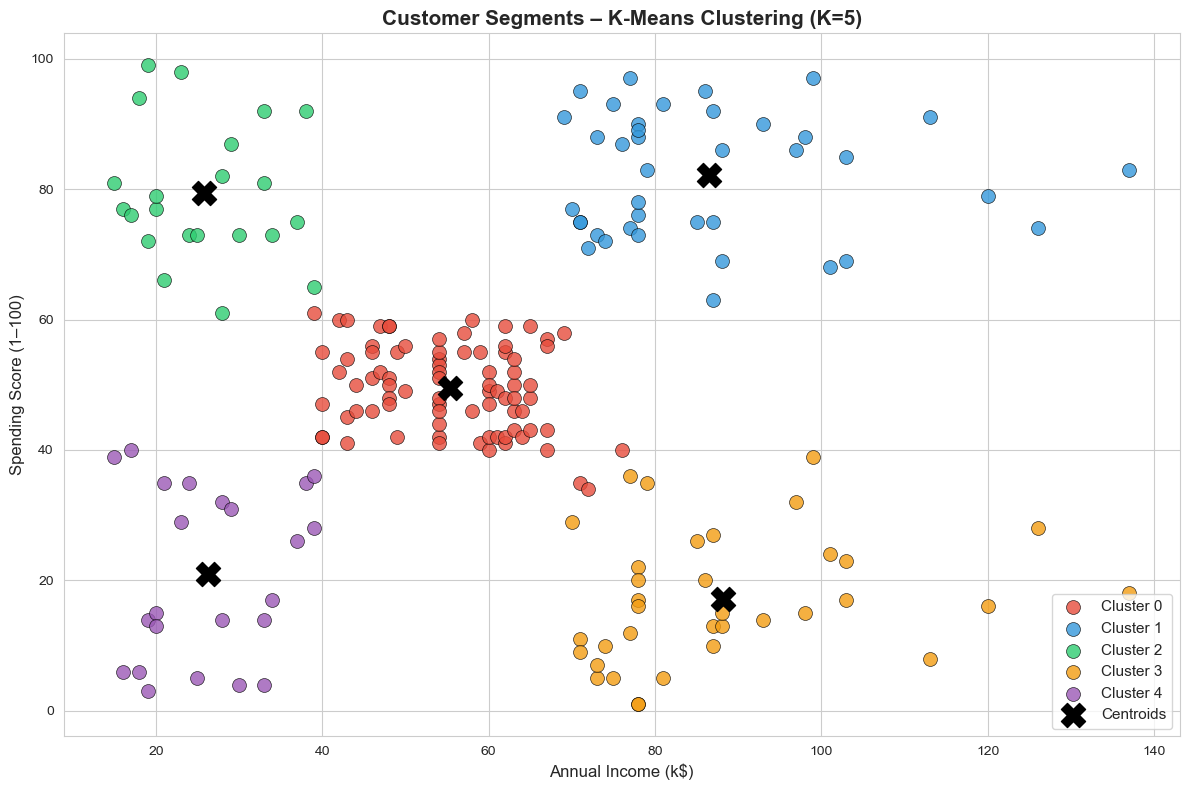

In [22]:
# Color palette for clusters
cluster_colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12', '#9B59B6']
cluster_names  = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

plt.figure(figsize=(12, 8))

for i in range(optimal_k):
    mask = df['Cluster_2D'] == i
    plt.scatter(df.loc[mask, 'Annual_Income'],
                df.loc[mask, 'Spending_Score'],
                s=100, c=cluster_colors[i], label=cluster_names[i],
                alpha=0.8, edgecolors='black', linewidth=0.5)

# Plotting centroids (inverse-transform them back to original scale)
centroids_orig = scaler.inverse_transform(kmeans_2d.cluster_centers_)
plt.scatter(centroids_orig[:, 0], centroids_orig[:, 1],
            s=300, c='black', marker='X', zorder=5, label='Centroids')

plt.title('Customer Segments – K-Means Clustering (K=5)', fontsize=15, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1–100)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('kmeans_clusters_2d.png', dpi=150, bbox_inches='tight')
plt.show()


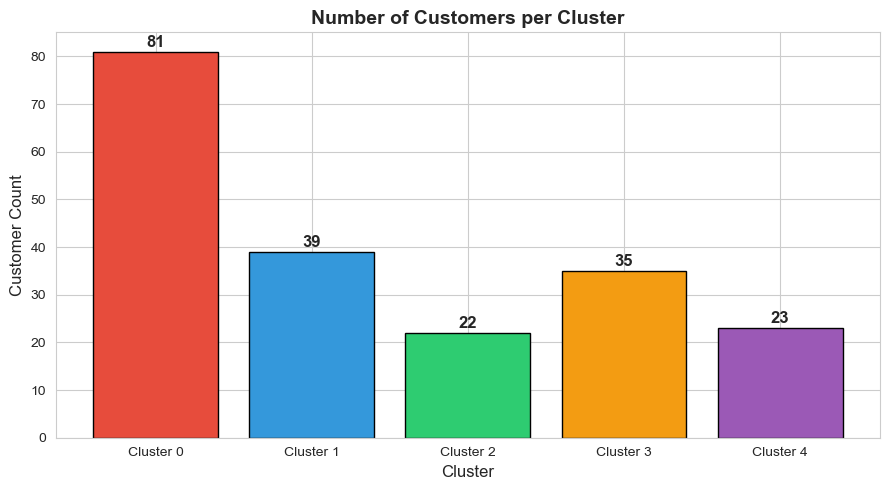

In [23]:
# Cluster size bar chart
cluster_counts = df['Cluster_2D'].value_counts().sort_index()
plt.figure(figsize=(9, 5))
bars = plt.bar(cluster_names, cluster_counts.values, color=cluster_colors, edgecolor='black')
for bar, val in zip(bars, cluster_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             str(val), ha='center', fontweight='bold', fontsize=12)
plt.title('Number of Customers per Cluster', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Customer Count')
plt.tight_layout()
plt.savefig('cluster_sizes.png', dpi=150, bbox_inches='tight')
plt.show()


## 📉 Section 10: Dimensionality Reduction – PCA & t-SNE

When clustering on multiple features, it helps to **reduce dimensions** to 2D so we can visualize the clusters effectively.

### PCA (Principal Component Analysis)
- Linear technique that finds directions of maximum variance
- Fast and deterministic
- Good for getting a general sense of cluster separation

### t-SNE (t-Distributed Stochastic Neighbor Embedding)
- Non-linear technique focused on preserving local neighborhood structure
- Better at revealing tight clusters
- Slower and stochastic (results may vary slightly between runs)


In [24]:
# ── PCA: Reducing 3D features to 2D ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_ * 100
print(f"📊 PCA Explained Variance:")
print(f"   PC1: {explained_variance[0]:.2f}%")
print(f"   PC2: {explained_variance[1]:.2f}%")
print(f"   Total: {sum(explained_variance):.2f}%")


📊 PCA Explained Variance:
   PC1: 44.27%
   PC2: 33.31%
   Total: 77.57%


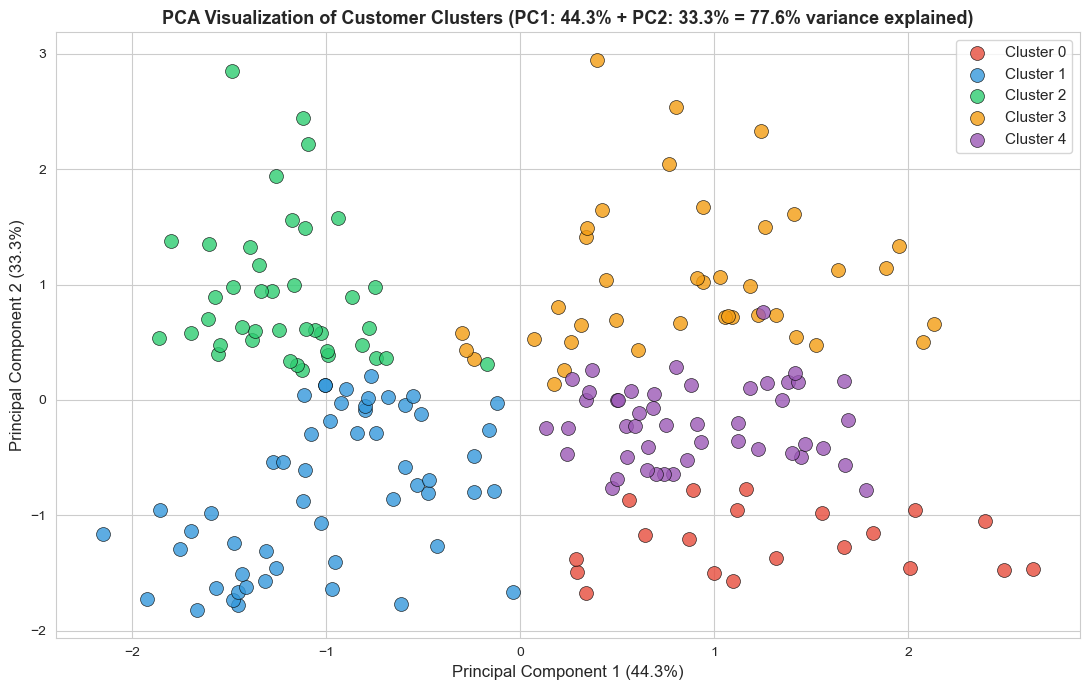

In [25]:
# PCA cluster visualization
plt.figure(figsize=(11, 7))
for i in range(optimal_k):
    mask = df['Cluster_3D'] == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                s=100, c=cluster_colors[i], label='Cluster ' + str(i),
                alpha=0.8, edgecolors='black', linewidth=0.5)

pca_title = ('PCA Visualization of Customer Clusters ('
             + 'PC1: ' + str(round(explained_variance[0], 1)) + '% + '
             + 'PC2: ' + str(round(explained_variance[1], 1)) + '% = '
             + str(round(sum(explained_variance), 1)) + '% variance explained)')
plt.title(pca_title, fontsize=13, fontweight='bold')
plt.xlabel('Principal Component 1 (' + str(round(explained_variance[0], 1)) + '%)')
plt.ylabel('Principal Component 2 (' + str(round(explained_variance[1], 1)) + '%)')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

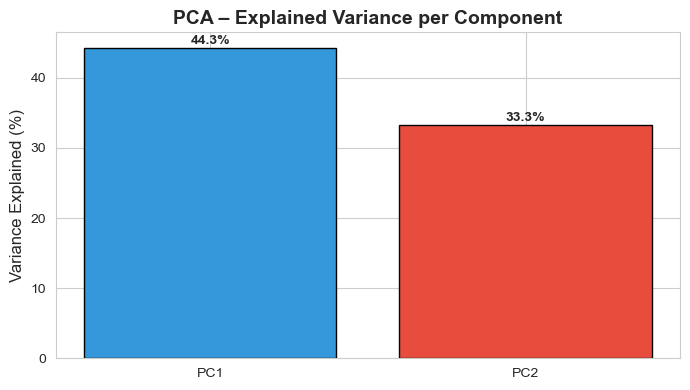

In [26]:
# PCA variance explained bar chart
plt.figure(figsize=(7, 4))
plt.bar(['PC1', 'PC2'], explained_variance, color=['#3498DB', '#E74C3C'], edgecolor='black')
for i, v in enumerate(explained_variance):
    plt.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')
plt.title('PCA – Explained Variance per Component', fontweight='bold')
plt.ylabel('Variance Explained (%)')
plt.tight_layout()
plt.savefig('pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()


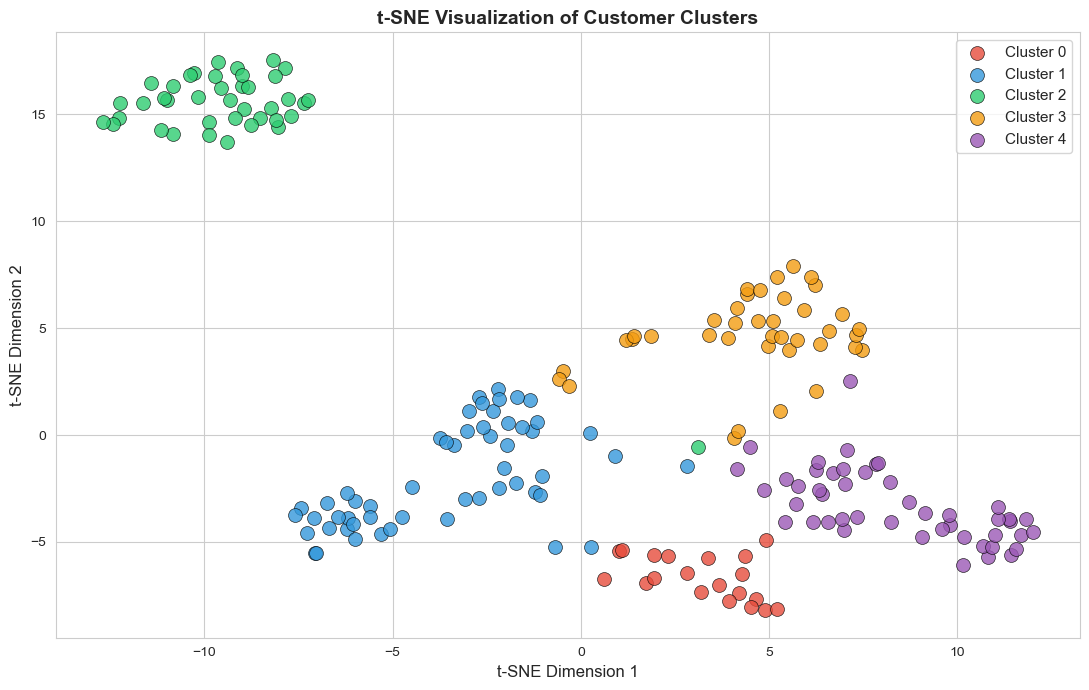

💡 t-SNE often reveals tighter, more separated clusters than PCA,
   but the axes don't have a direct interpretable meaning.


In [27]:
# ── t-SNE: Non-linear dimensionality reduction ──────────────────────────────
# perplexity is typically between 5 and 50; 30 works well for this dataset size
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, learning_rate='auto', init='pca')
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(11, 7))
for i in range(optimal_k):
    mask = df['Cluster_3D'] == i
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                s=100, c=cluster_colors[i], label=f'Cluster {i}',
                alpha=0.8, edgecolors='black', linewidth=0.5)

plt.title('t-SNE Visualization of Customer Clusters', fontsize=14, fontweight='bold')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('tsne_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 t-SNE often reveals tighter, more separated clusters than PCA,")
print("   but the axes don't have a direct interpretable meaning.")


## 👥 Section 11: Customer Segment Analysis

Now we analyse each cluster individually to understand **who these customers are** and how they behave. We use the 2D model (Income × Spending Score) since it's the most intuitive.

We'll assign descriptive business labels to each cluster.


In [28]:
# Detailed cluster profiling
print("=" * 65)
print("          CUSTOMER SEGMENT PROFILES")
print("=" * 65)

cluster_labels = {
    0: '🎯 Sensible Savers (Mid Income, Low Spenders)',
    1: '💎 Premium Customers (High Income, High Spenders)',
    2: '🛒 Budget Shoppers (Low Income, Low Spenders)',
    3: '⭐ Careless Spenders (Low Income, High Spenders)',
    4: '💰 Conservative Elites (High Income, Low Spenders)'
}

# Re-identify clusters based on their centroids
centroids_df = pd.DataFrame(centroids_orig, columns=['Annual_Income', 'Spending_Score'])
centroids_df['Cluster'] = range(optimal_k)
centroids_df = centroids_df.sort_values('Annual_Income')
print("\nCluster Centroids (original scale):")
print(centroids_df.to_string(index=False))

# Full stats per cluster
for cluster_id in sorted(df['Cluster_2D'].unique()):
    subset = df[df['Cluster_2D'] == cluster_id]
    print(f"\n{'─'*60}")
    print(f"  Cluster {cluster_id}  |  {len(subset)} customers")
    print(f"{'─'*60}")
    print(f"  Avg Age            : {subset['Age'].mean():.1f} years")
    print(f"  Avg Annual Income  : ${subset['Annual_Income'].mean():.1f}k")
    print(f"  Avg Spending Score : {subset['Spending_Score'].mean():.1f} / 100")
    print(f"  Gender split       : {subset['Gender'].value_counts().to_dict()}")


          CUSTOMER SEGMENT PROFILES

Cluster Centroids (original scale):
 Annual_Income  Spending_Score  Cluster
     25.727273       79.363636        2
     26.304348       20.913043        4
     55.296296       49.518519        0
     86.538462       82.128205        1
     88.200000       17.114286        3

────────────────────────────────────────────────────────────
  Cluster 0  |  81 customers
────────────────────────────────────────────────────────────
  Avg Age            : 42.7 years
  Avg Annual Income  : $55.3k
  Avg Spending Score : 49.5 / 100
  Gender split       : {'Female': 48, 'Male': 33}

────────────────────────────────────────────────────────────
  Cluster 1  |  39 customers
────────────────────────────────────────────────────────────
  Avg Age            : 32.7 years
  Avg Annual Income  : $86.5k
  Avg Spending Score : 82.1 / 100
  Gender split       : {'Female': 21, 'Male': 18}

────────────────────────────────────────────────────────────
  Cluster 2  |  22 custom

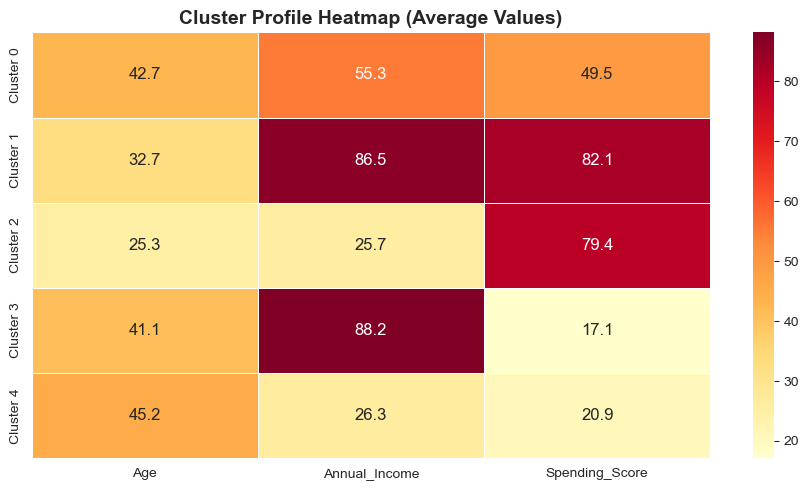

In [29]:
# Heatmap of cluster averages — easy executive-level view
cluster_avg = df.groupby('Cluster_2D')[['Age', 'Annual_Income', 'Spending_Score']].mean()
cluster_avg.index = [f'Cluster {i}' for i in cluster_avg.index]

plt.figure(figsize=(9, 5))
sns.heatmap(cluster_avg, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 12})
plt.title('Cluster Profile Heatmap (Average Values)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


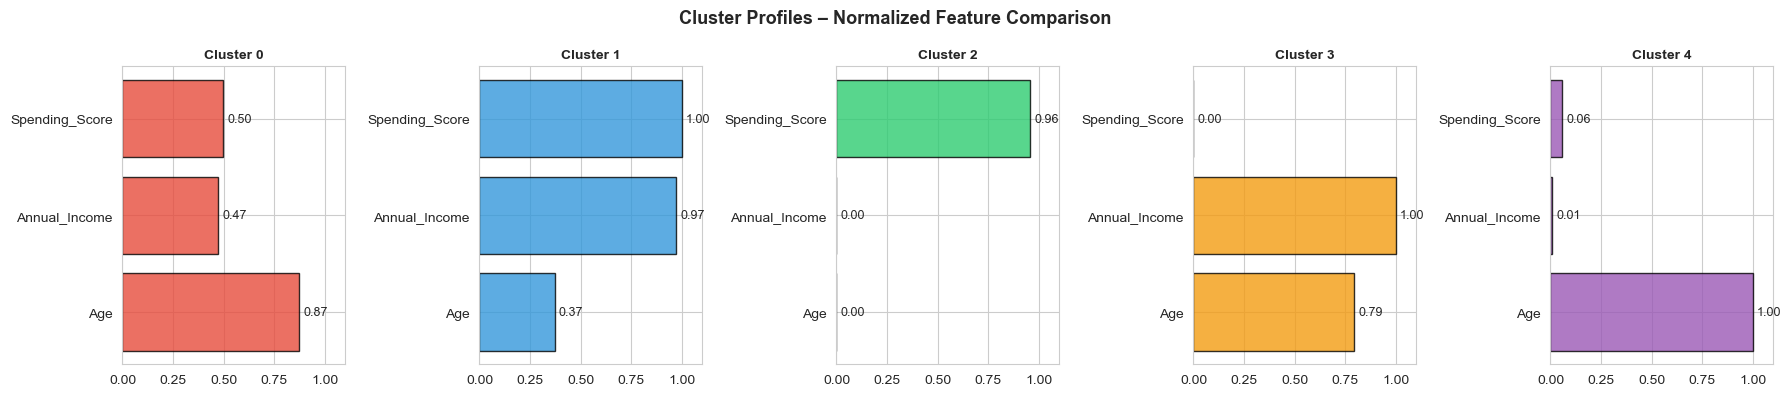

In [30]:
# Radar/spider chart comparing clusters across all three dimensions
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ['Age', 'Annual_Income', 'Spending_Score']
# Normalize to 0-1 for fair radar comparison
cluster_norm = (cluster_avg - cluster_avg.min()) / (cluster_avg.max() - cluster_avg.min())

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for idx, (cluster_name, row) in enumerate(cluster_norm.iterrows()):
    ax = axes[idx]
    ax.barh(categories, row.values, color=cluster_colors[idx], edgecolor='black', alpha=0.8)
    ax.set_xlim(0, 1.1)
    ax.set_title(cluster_name, fontweight='bold', fontsize=10)
    for i, v in enumerate(row.values):
        ax.text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)

plt.suptitle('Cluster Profiles – Normalized Feature Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()


## 📣 Section 12: Marketing Strategy Recommendations

Based on our cluster analysis, here are **data-driven, tailored marketing strategies** for each customer segment.

---

### 🎯 Cluster 0 — Sensible Savers (Mid Income, Low Spending)
**Profile:** Middle-income earners who are conservative with their mall spending.

**Strategies:**
- **Value bundles & combo deals** — Show them the savings, not the price
- **Loyalty points programs** — Reward them for each visit to gradually increase frequency
- **Clearance sale alerts** — Send early access emails for discounts
- **Cashback offers** — A compelling reason to spend more per visit

---

### 💎 Cluster 1 — Premium Customers (High Income, High Spending)
**Profile:** The mall's most valuable customers. They earn well and spend freely.

**Strategies:**
- **VIP membership programs** — Exclusive lounges, personal shoppers, priority billing
- **Premium product launches** — Invite them to preview events before public launch
- **Luxury brand partnerships** — Curated newsletters from high-end brands
- **Personalized experience** — Birthday rewards, anniversary surprises, dedicated staff

---

### 🛒 Cluster 2 — Budget Shoppers (Low Income, Low Spending)
**Profile:** Cost-conscious shoppers with limited purchasing power.

**Strategies:**
- **Discount coupons & vouchers** — Direct incentive to visit more often
- **Budget-friendly product range** — Promote affordable items prominently
- **Student & senior discounts** — Many in this group may be students or retirees
- **Flash sales & daily deals** — Create urgency without requiring a big wallet

---

### ⭐ Cluster 3 — Careless Spenders (Low Income, High Spending)
**Profile:** Impulsive buyers with limited income who spend aggressively at the mall.

**Strategies:**
- **Buy Now Pay Later (BNPL) options** — Reduce upfront burden, increase purchase size
- **Impulse-buy product placement** — Position attractive items at checkout areas
- **Social media influencer campaigns** — This group is likely young and trend-driven
- **Limited edition collections** — Scarcity triggers impulsive purchase decisions

---

### 💰 Cluster 4 — Conservative Elites (High Income, Low Spending)
**Profile:** Wealthy customers who do not spend proportionally to their income at this mall.

**Strategies:**
- **Exclusive high-value offers** — Make them feel special, not just sold to
- **Premium consultation services** — Style consultants, home décor experts, etc.
- **Referral reward programs** — Leverage their social networks
- **Quality storytelling** — Market craftsmanship, heritage, and exclusivity — not discounts

---


## 💼 Section 13: Business Insights


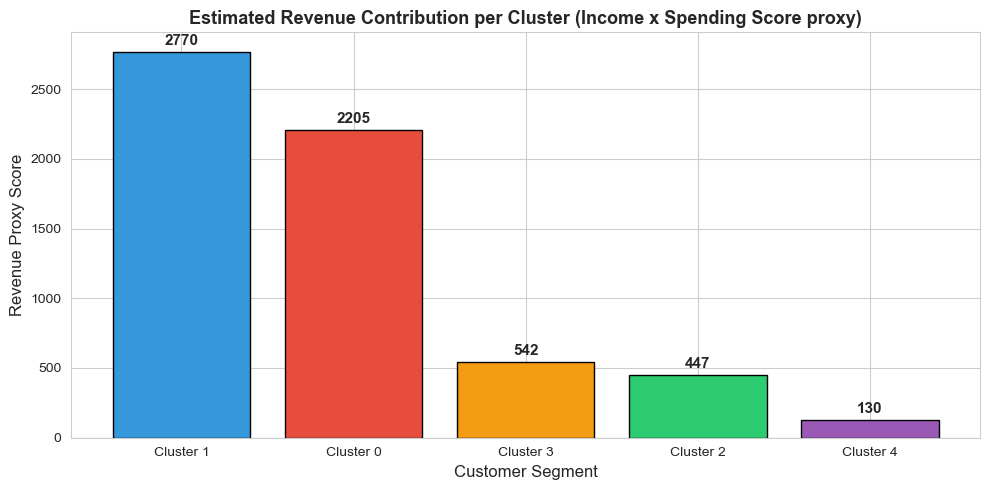

Key Business Insights:
   1. Premium Customers generate the highest revenue - protect them at all costs.
   2. Careless Spenders spend above their means - BNPL strategies can boost sales here.
   3. Conservative Elites are UNTAPPED - they have money but are not spending it.
   4. Budget Shoppers need low-friction offers to increase visit frequency.
   5. Sensible Savers respond best to value-based marketing - show ROI, not luxury.


In [31]:
# Revenue contribution simulation (Spending Score x Income as proxy)
df['Revenue_Proxy'] = df['Annual_Income'] * df['Spending_Score'] / 100

revenue_by_cluster = df.groupby('Cluster_2D')['Revenue_Proxy'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
bars = plt.bar(['Cluster ' + str(i) for i in revenue_by_cluster.index],
               revenue_by_cluster.values,
               color=[cluster_colors[i] for i in revenue_by_cluster.index],
               edgecolor='black')
for bar, val in zip(bars, revenue_by_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(round(val)), ha='center', fontweight='bold', fontsize=11)

plt.title('Estimated Revenue Contribution per Cluster (Income x Spending Score proxy)',
          fontsize=13, fontweight='bold')
plt.xlabel('Customer Segment')
plt.ylabel('Revenue Proxy Score')
plt.tight_layout()
plt.savefig('revenue_by_cluster.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Business Insights:")
print("   1. Premium Customers generate the highest revenue - protect them at all costs.")
print("   2. Careless Spenders spend above their means - BNPL strategies can boost sales here.")
print("   3. Conservative Elites are UNTAPPED - they have money but are not spending it.")
print("   4. Budget Shoppers need low-friction offers to increase visit frequency.")
print("   5. Sensible Savers respond best to value-based marketing - show ROI, not luxury.")

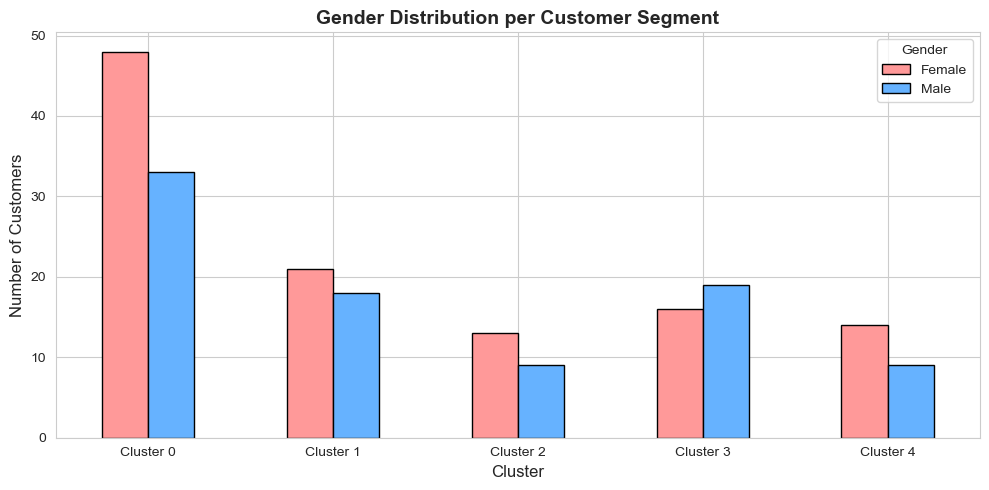

In [32]:
# Gender breakdown per cluster
gender_cluster = pd.crosstab(df['Cluster_2D'], df['Gender'])
gender_cluster.plot(kind='bar', color=['#FF9999', '#66B2FF'],
                    edgecolor='black', figsize=(10, 5))
plt.title('Gender Distribution per Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Number of Customers')
plt.xticks([i for i in range(5)], [f'Cluster {i}' for i in range(5)], rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.savefig('gender_per_cluster.png', dpi=150, bbox_inches='tight')
plt.show()


## 🏁 Section 14: Final Conclusion

---

### ✅ Project Summary

In this project, we successfully:

1. **Explored** the Mall Customers dataset through comprehensive EDA — understanding distributions, correlations, and spending patterns across demographics.

2. **Preprocessed** the data by selecting meaningful features and scaling them for clustering compatibility.

3. **Determined the optimal number of clusters (K=5)** using both the **Elbow Method** and **Silhouette Score Analysis**.

4. **Applied K-Means Clustering** to identify 5 distinct customer segments with unique behavioral profiles.

5. **Visualized clusters** using direct 2D scatter plots, **PCA**, and **t-SNE** to confirm well-separated customer groups.

6. **Analysed each segment** in depth and developed **targeted marketing strategies** aligned with each group's behavior and purchasing power.

---

### 🔑 Key Findings

| Cluster | Label | Key Insight |
|---|---|---|
| 0 | Sensible Savers | Moderate earners who need value-based incentives |
| 1 | Premium Customers | High earners, high spenders — the mall's most valuable segment |
| 2 | Budget Shoppers | Low income, low spending — respond to discounts and flash sales |
| 3 | Careless Spenders | Impulsive buyers — benefit from BNPL and social campaigns |
| 4 | Conservative Elites | High earners who are NOT spending — a major untapped opportunity |

---

### 📈 Business Impact

- The mall can now **personalize campaigns** instead of using blanket marketing
- **Budget allocation** can shift toward highest-ROI segments (Clusters 1 & 4)
- **Customer retention** improves when people feel understood and catered to
- **New revenue streams** open up by engaging Conservative Elites and Careless Spenders differently

---

### 🚀 Future Improvements

- Add **purchase transaction data** for more granular behavioral clustering
- Apply **DBSCAN** or **Hierarchical Clustering** to compare against K-Means results
- Use **RFM Analysis** (Recency, Frequency, Monetary) for deeper customer value modeling
- Integrate **real-time data pipelines** for dynamic cluster reassignment as customer behavior changes
- Build a **dashboard** (e.g., Streamlit or Dash) for business stakeholders to explore segments interactively

---

> *"The goal is to turn data into information, and information into insight."*  
> — Carly Fiorina, former CEO of HP

---
